[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Digdgeo/Ndvi2Gif/blob/master/workshops/ecoinformatica/notebooks/03_fenologia.ipynb)

# Fenología: cuándo despierta cada cultivo

**Taller Ndvi2Gif — Jornadas de Ecoinformática, Sevilla, 2 de octubre de 2026**

Un recuadro de 29 × 26 km a caballo del Guadalquivir, con dos paisajes agrícolas muy
distintos dentro: al norte las tablas de **arroz** de Isla Mayor y Los Palacios, que se
inundan en primavera y se cosechan en septiembre; al sur y al este, sobre marisma
colonizada, el **mosaico de Lebrija y Las Cabezas** — algodón, girasol, remolacha,
hortícolas, regadío y secano mezclados parcela a parcela.

Dos fenologías en la misma imagen es lo mejor que le puede pasar a este notebook, porque lo
que hace `SpatialPhenologyAnalyzer` es precisamente **sacar fechas** píxel a píxel de una
serie de compuestos, y aquí las fechas cambian de una parcela a la de al lado.

Cuatro métricas, y todas en día del año (DOY):

| sigla | qué es |
|---|---|
| **SOS** | *start of season*, el arranque |
| **POS** | *peak of season*, el máximo |
| **EOS** | *end of season*, el final |
| **LOS** | *length of season*, EOS − SOS |

In [1]:
# !pip install -q ndvi2gif

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='geemap.conversion')

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlopen
from PIL import Image
from io import BytesIO

from ndvi2gif import NdviSeasonality, SpatialPhenologyAnalyzer

# ee.Authenticate()        # solo la primera vez
PROJECT = 'tu-proyecto-de-earth-engine'
ee.Initialize(project=PROJECT)
print('✓ Earth Engine listo')

DOY_VIS = {'min': 60, 'max': 330,
           'palette': ['#2c7bb6', '#abd9e9', '#ffffbf', '#fdae61', '#d7191c']}
LOS_VIS = {'min': 60, 'max': 240, 'palette': ['#ffffcc', '#78c679', '#006837']}


def miniatura(imagen, vis, region, dimensiones=440):
    url = imagen.visualize(**vis).getThumbURL(
        {'region': region, 'dimensions': dimensiones, 'format': 'png'})
    return np.array(Image.open(BytesIO(urlopen(url).read())))

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


✓ Earth Engine listo


## 1. La zona

En color natural y en pleno julio se ven los dos paisajes de un vistazo. Arriba, las tablas
de arroz: bloques grandes y de un verde muy oscuro, con los canales marcando la cuadrícula
y alguna tabla en barbecho clarísima al lado. Abajo a la derecha, el mosaico: parcelas
pequeñas, cada una de un tono, porque cada cultivo va por su sitio del calendario.

ROI: 138 km²


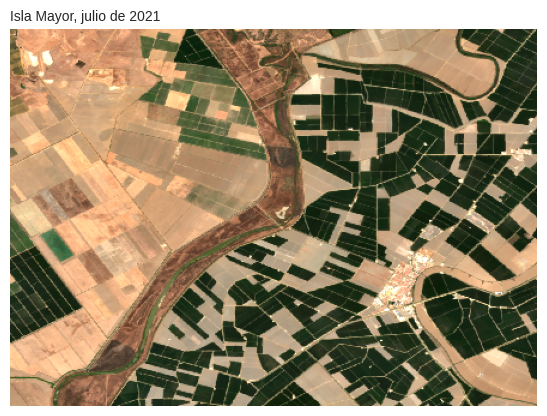

In [2]:
roi = ee.Geometry.Rectangle([-6.25, 36.95, -5.92, 37.18])
print('ROI: %.0f km²' % (roi.area(100).getInfo() / 1e6))

verano = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(roi).filterDate('2021-07-01', '2021-08-31')
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)).median())

fig, ax = plt.subplots(figsize=(5.6, 4.8))
ax.imshow(miniatura(verano, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500}, roi))
ax.set_title('Isla Mayor, julio de 2021', loc='left', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Doce compuestos al año

La fenología necesita resolución temporal, así que aquí `periods=12` (un compuesto por mes)
y `key='median'`, que es el reductor honesto: el máximo mensual se contamina con cualquier
píxel raro y adelanta artificialmente el arranque de la estación.

`SpatialPhenologyAnalyzer` se monta sobre el `NdviSeasonality`, igual que el analizador de
hidroperiodo.

In [3]:
procesador = NdviSeasonality(roi=roi, periods=12, start_year=2019, end_year=2022,
                             sat='S2', index='ndvi', key='median')
pheno = SpatialPhenologyAnalyzer(procesador)

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


## 3. La estación típica

`phenology_summary()` resume los cuatro años en un solo mapa por métrica: la fenología
mediana del arrozal. Azul = temprano, rojo = tardío.

bandas: ['sos', 'pos', 'eos', 'los', 'amplitude', 'peak_value', 'baseline', 'growth_rate', 'senescence_rate']


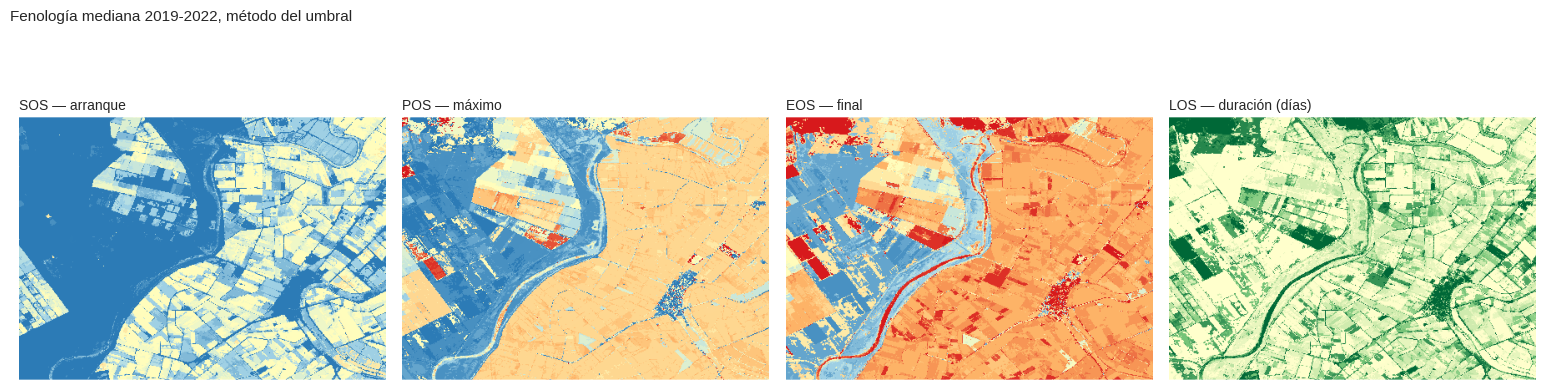

In [4]:
resumen = pheno.phenology_summary(method='threshold', reducer='median')
print('bandas:', resumen.bandNames().getInfo())

fig, axes = plt.subplots(1, 4, figsize=(15.5, 4.4))
for ax, (banda, vis, titulo) in zip(axes, [
        ('sos', DOY_VIS, 'SOS — arranque'),
        ('pos', DOY_VIS, 'POS — máximo'),
        ('eos', DOY_VIS, 'EOS — final'),
        ('los', LOS_VIS, 'LOS — duración (días)')]):
    ax.imshow(miniatura(resumen.select(banda), vis, roi))
    ax.set_title(titulo, loc='left', fontsize=10)
    ax.axis('off')
fig.suptitle('Fenología mediana 2019-2022, método del umbral', x=0.005, ha='left',
             fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [5]:
METRICAS = ['sos', 'pos', 'eos', 'los', 'amplitude']
valores = resumen.select(METRICAS).reduceRegion(
    reducer=ee.Reducer.median().combine(ee.Reducer.percentile([10, 90]),
                                        sharedInputs=True),
    geometry=roi, scale=60, maxPixels=1e9, bestEffort=True, tileScale=4).getInfo()

tabla = pd.DataFrame({'p10': {m: valores[m + '_p10'] for m in METRICAS},
                      'mediana': {m: valores[m + '_median'] for m in METRICAS},
                      'p90': {m: valores[m + '_p90'] for m in METRICAS}})
tabla.round(1)

,p10,mediana,p90
sos,16.0,106.5,197.1
pos,75.3,228.4,243.4
eos,90.3,258.3,289.3
los,46.0,76.5,211.5
amplitude,0.4,0.7,1.0


RESULTADO_CALENDARIO

### Dos paisajes, dos calendarios

La mediana de todo el recuadro mezcla dos cosas que no se parecen, así que vamos a mirarlas
por separado — pero con cuidado con lo que se puede promediar y lo que no. El arrozal es un
cultivo uniforme y su mediana significa algo. El mosaico de Lebrija **no**: ahí conviven
algodón, girasol, remolacha y hortícolas en parcelas contiguas, y una mediana de todo eso
no describe a ninguno. Lo que hay que mirar ahí es el **mapa**, y lo que se puede medir es
cuánto se dispersan las fechas.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))
for ax, (nombre, geometria) in zip(axes, ZONAS.items()):
    ax.imshow(miniatura(resumen.select('sos'), DOY_VIS, geometria, dimensiones=520))
    ax.set_title('%s — SOS (día del año)' % nombre, loc='left', fontsize=10)
    ax.axis('off')
fig.suptitle('El mismo mapa de arranque de estación, en las dos zonas',
             x=0.005, ha='left', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [ ]:
# del arrozal, la mediana; de las dos, la dispersión — que es lo que las separa
peticion = ee.List([
    ee.Dictionary(resumen.select(['sos']).reduceRegion(
        ee.Reducer.percentile([10, 50, 90]).combine(ee.Reducer.stdDev(),
                                                    sharedInputs=True),
        geometria, 60, maxPixels=1e9, bestEffort=True,
        tileScale=4)).set('zona', nombre)
    for nombre, geometria in ZONAS.items()])

por_zona = pd.DataFrame(peticion.getInfo()).set_index('zona')
por_zona = por_zona.rename(columns={'sos_p10': 'SOS p10', 'sos_p50': 'SOS mediano',
                                    'sos_p90': 'SOS p90', 'sos_stdDev': 'desv. típica'})
por_zona['p90 − p10'] = por_zona['SOS p90'] - por_zona['SOS p10']
por_zona.round(1)

RESULTADO_ZONAS

## 4. Tres métodos y tres respuestas

"Cuándo empieza la estación" no tiene una sola definición. La librería trae tres:

- **`threshold`** — el día en que el NDVI pasa un porcentaje de la amplitud del año
  (por defecto el 20 %). Es el estándar de la bibliografía de fenología de satélite.
- **`derivative`** — el día de máxima pendiente, el momento de crecimiento más rápido.
- **`harmonic`** — se ajusta una curva de senos y cosenos al año y se fechan sus puntos
  notables. Suaviza mucho, y ahí está su problema.

In [6]:
METODOS = ['threshold', 'derivative', 'harmonic']
sos = {m: pheno.phenology_summary(method=m).select('sos') for m in METODOS}

filas = {}
for m, imagen in sos.items():
    filas[m] = imagen.reduceRegion(
        reducer=ee.Reducer.median().combine(ee.Reducer.stdDev(), sharedInputs=True),
        geometry=roi, scale=60, maxPixels=1e9, bestEffort=True, tileScale=4).getInfo()

pd.DataFrame({'SOS mediano (DOY)': {m: filas[m]['sos_median'] for m in METODOS},
              'dispersión (desv. típica, días)': {m: filas[m]['sos_stdDev']
                                                  for m in METODOS}}).round(1)

,SOS mediano (DOY),"dispersión (desv. típica, días)"
threshold,106.5,69.3
derivative,182.0,73.5
harmonic,61.0,58.9


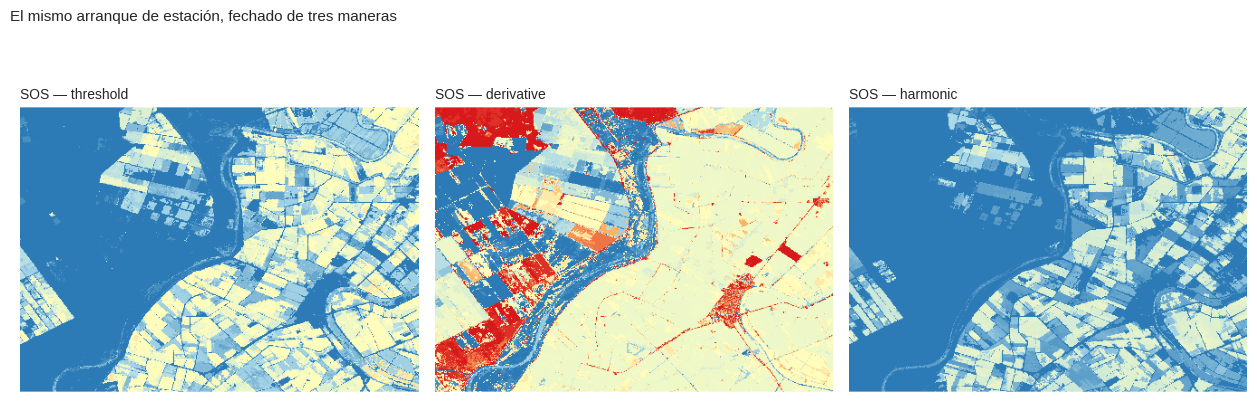

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.4))
for ax, m in zip(axes, METODOS):
    ax.imshow(miniatura(sos[m], DOY_VIS, roi))
    ax.set_title('SOS — %s' % m, loc='left', fontsize=10)
    ax.axis('off')
fig.suptitle('El mismo arranque de estación, fechado de tres maneras', x=0.005,
             ha='left', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

El armónico sale **antes** que los otros dos, y no es un error del código: con dos
armónicos la curva no puede subir tan rápido como sube de verdad un cultivo de regadío que
pasa de suelo desnudo a dosel cerrado en seis semanas, así que coloca el arranque y el
máximo demasiado pronto. La solución es darle más armónicos.

In [8]:
prueba = []
for n in [2, 3, 4]:
    imagen = pheno.phenology_summary(method='harmonic', n_harmonics=n)
    v = imagen.select(['sos', 'pos', 'eos', 'los']).reduceRegion(
        ee.Reducer.median(), roi, scale=60, maxPixels=1e9, bestEffort=True,
        tileScale=4).getInfo()
    prueba.append({'n_harmonics': n, **{k: v[k] for k in ['sos', 'pos', 'eos', 'los']}})

print('para comparar, método del umbral: SOS %.0f, POS %.0f'
      % (filas['threshold']['sos_median'], tabla.loc['pos', 'mediana']))
pd.DataFrame(prueba).set_index('n_harmonics').round(0)

para comparar, método del umbral: SOS 106, POS 228


,sos,pos,eos,los
n_harmonics,,,,
2,61.0,171.0,271.0,110.0
3,96.0,221.0,266.0,95.0
4,71.0,221.0,266.0,105.0


## 5. Año a año: los años en que el arroz no ocurrió

Hasta aquí todo eran medianas de cuatro años. `extract_phenology_rasters()` da un ráster
por año, y es donde aparece lo interesante — porque estos fueron años de sequía, y en el
Guadalquivir una sequía no reparte igual: el arroz depende de que le asignen agua, y hubo
años en que **se recortó la superficie sembrada** hasta casi hacerla desaparecer, mientras
el regadío del mosaico seguía con lo suyo.

El filtro es la amplitud: por debajo de 0,3 de recorrido de NDVI, ese píxel no tuvo
estación y su SOS es ruido.

In [9]:
anuales = pheno.extract_phenology_rasters(method='threshold')
anios = list(range(procesador.start_year, procesador.end_year + 1))
print('%d imágenes, una por año' % anuales.size().getInfo())

AMPLITUD = 0.3        # por debajo de esto el píxel no tuvo estación

por_anio = []
for anio in anios:
    imagen = ee.Image(anuales.filter(ee.Filter.eq('year', anio)).first())
    estacional = imagen.updateMask(imagen.select('amplitude').gte(AMPLITUD))
    fechas = estacional.select(['sos', 'eos', 'los']).reduceRegion(
        ee.Reducer.median(), roi, scale=60, maxPixels=1e9, bestEffort=True,
        tileScale=4).getInfo()
    # mask().mean() sobre el ROI es la fracción de píxeles que pasan el filtro
    parte = estacional.select('sos').mask().reduceRegion(
        ee.Reducer.mean(), roi, scale=60, maxPixels=1e9, bestEffort=True,
        tileScale=4).getInfo()['sos']
    por_anio.append({'año': anio, **{k: fechas[k] for k in ['sos', 'eos', 'los']},
                     'superficie con estación': parte})

por_anio = pd.DataFrame(por_anio).set_index('año')
por_anio.round(2)

4 imágenes, una por año


,sos,eos,los,superficie con estación
año,,,,
2019,166.0,228.0,62.00,0.93
2020,198.0,290.0,92.00,0.94
2021,45.0,258.0,61.00,0.79
2022,105.0,258.0,60.78,0.56


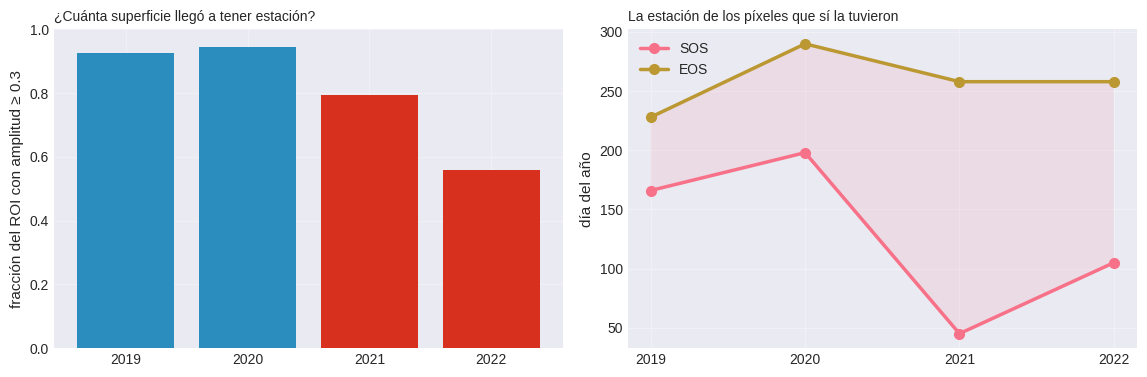

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.9))
axes[0].bar(por_anio.index.astype(str), por_anio['superficie con estación'],
            color=['#2b8cbe' if v > 0.8 else '#d7301f'
                   for v in por_anio['superficie con estación']])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('fracción del ROI con amplitud ≥ %.1f' % AMPLITUD)
axes[0].set_title('¿Cuánta superficie llegó a tener estación?', loc='left', fontsize=10)

axes[1].plot(por_anio.index, por_anio['sos'], 'o-', label='SOS')
axes[1].plot(por_anio.index, por_anio['eos'], 'o-', label='EOS')
axes[1].fill_between(por_anio.index, por_anio['sos'], por_anio['eos'], alpha=0.12)
axes[1].set_ylabel('día del año')
axes[1].set_xticks(por_anio.index)
axes[1].set_title('La estación de los píxeles que sí la tuvieron', loc='left', fontsize=10)
axes[1].legend(frameon=False)

for ax in axes:
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)
plt.tight_layout()
plt.show()

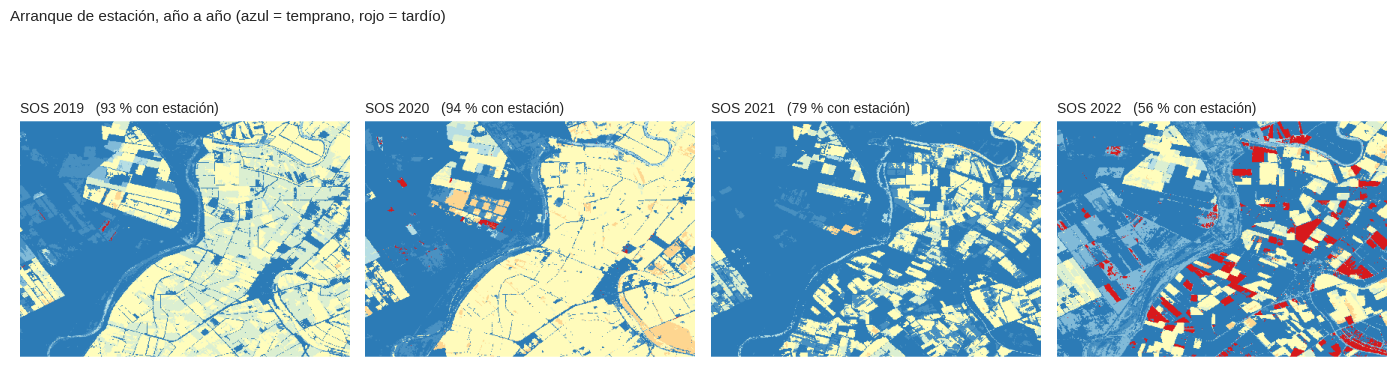

In [11]:
fig, axes = plt.subplots(1, len(anios), figsize=(3.5 * len(anios), 4.2))
for ax, anio in zip(axes, anios):
    imagen = ee.Image(anuales.filter(ee.Filter.eq('year', anio)).first())
    ax.imshow(miniatura(imagen.select('sos'), DOY_VIS, roi))
    ax.set_title('SOS %d   (%.0f %% con estación)'
                 % (anio, 100 * por_anio.loc[anio, 'superficie con estación']),
                 loc='left', fontsize=10)
    ax.axis('off')
fig.suptitle('Arranque de estación, año a año (azul = temprano, rojo = tardío)',
             x=0.005, ha='left', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

RESULTADO_ANIOS


## 6. Tu zona, tu GeoTIFF

Ahora te toca. Dibuja en el mapa un polígono **pequeño** —una o dos parcelas del mosaico,
un par de kilómetros cuadrados como mucho— con la barra de herramientas de la izquierda.
Cada uno la suya: no hay dos parcelas con el mismo calendario, que es justo la gracia.

Con eso calculamos su fenología y la bajamos como GeoTIFF para abrirla en QGIS.

In [ ]:
MapaDibujo = geemap.Map(center=[37.02, -6.02], zoom=12)
MapaDibujo.add_basemap('SATELLITE')
MapaDibujo

In [ ]:
mi_zona = MapaDibujo.user_roi
if mi_zona is None:
    # por si ejecutas el notebook de un tirón: un trozo del mosaico de Lebrija
    mi_zona = ee.Geometry.Rectangle([-6.04, 36.99, -6.01, 37.01])
    print('no hay nada dibujado, uso un recuadro de ejemplo')
print('tu zona: %.1f km²' % (mi_zona.area(10).getInfo() / 1e6))

mi_pheno = SpatialPhenologyAnalyzer(
    NdviSeasonality(roi=mi_zona, periods=12, start_year=2019, end_year=2022,
                    sat='S2', index='ndvi', key='median'))

# export=True escribe el GeoTIFF en el directorio de trabajo, con los nombres de las
# bandas dentro del fichero. A 20 m y un par de km² la descarga directa va sobrada;
# para áreas grandes hay que usar export_target='drive'
mi_resumen = mi_pheno.phenology_summary(method='threshold', reducer='median',
                                        export=True, export_target='local', scale=20)

In [ ]:
FICHERO = 'S2_ndvi_phenology_threshold_median_2019_2022.tif'

try:                                    # en Colab, al ordenador del alumno
    from google.colab import files
    files.download(FICHERO)
except ImportError:                     # en local, ya está en disco
    import os
    print('escrito en', os.path.join(os.getcwd(), FICHERO))

Ábrelo en **QGIS** (o en Geolibre) y verás nueve bandas con su nombre puesto: `sos`, `pos`,
`eos`, `los`, `amplitude`, `peak_value`, `baseline`, `growth_rate` y `senescence_rate`.

Dos cosas para que se vea bien a la primera:

- carga la banda `sos` sola, con una rampa de color y el rango ajustado a tus datos
  (botón derecho → *Propiedades* → *Simbología* → *Banda única pseudocolor*);
- y pon debajo la ortofoto del PNOA, que es cuando se entiende: cada parcela es de un color
  porque cada una se sembró su día.

## 7. Sacarlo todo de golpe

Las dos funciones exportan directamente, a local o a Drive:

```python
# un GeoTIFF con las métricas medianas
pheno.phenology_summary(method='harmonic', reducer='median',
                        export=True, export_target='local', scale=20)

# un GeoTIFF por año, a Drive (mejor para áreas grandes)
pheno.extract_phenology_rasters(method='harmonic', export=True,
                                export_target='drive',
                                drive_folder='ndvi2gif_fenologia', scale=20)
```

## Las perillas que importan

| parámetro | qué hace |
|---|---|
| `periods` | resolución temporal. Con menos de 12 no hay fenología que sacar |
| `key` | `'median'` para fenología; `'max'` adelanta el arranque |
| `method` | `threshold`, `derivative` o `harmonic` |
| `n_harmonics` | 2 suaviza de más en cultivos; 3 va mejor |
| `amplitude` | el filtro de "aquí no hubo estación" |

- El libro, con la versión larga: **https://digdgeo.github.io/Ndvi2Gif/**
- Y los dos notebooks anteriores del taller: `01_rois_y_estadisticos.ipynb` y
  `02_hidroperiodo.ipynb`.